In [6]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
from sklearn.cluster import KMeans


# Exploration

In [7]:
from google.colab import drive
drive.mount('/content/drive')
# list files in the folder
print(os.listdir("/content/drive/MyDrive/DMT_data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test_set_VU_DM.csv', 'training_set_VU_DM.csv', 'DMT_A2.ipynb', 'DMT_data']


In [8]:
#!ln -s "/content/drive/MyDrive/DMT_data" /content/DMT_data
# This should now show your data
#!ls /content/DMT_data

Plot style

In [9]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

## Read data

In [10]:
data_path = '/content/DMT_data'
train_file = os.path.join(data_path, 'training_set_VU_DM.csv')
test_file = os.path.join(data_path, 'test_set_VU_DM.csv')

train_df = pd.read_csv(train_file)
df = train_df.copy()
display(df.head())
#test = pd.read_csv(test_file)

FileNotFoundError: [Errno 2] No such file or directory: '/content/DMT_data/training_set_VU_DM.csv'

### Nulls

In [ ]:
#df.columns.tolist()
df.isnull().sum()

,0
srch_id,0
date_time,0
site_id,0
visitor_location_country_id,0
visitor_hist_starrating,4706481
visitor_hist_adr_usd,4705359
prop_country_id,0
prop_id,0
prop_starrating,0
prop_review_score,7364


In [5]:
# % of missing values per row
df['missing_row_pct'] = (df.isnull().sum(axis=1) / len(df.columns)) * 100

# summary
print(df['missing_row_pct'].describe())

NameError: name 'df' is not defined

In [ ]:
# checking if any rows are droppped due to datetime
initial_count = len(df)
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
valid_count = df['date_time'].notna().sum()

dropped_rows = initial_count - valid_count
print(f"Total rows dropped: {dropped_rows}")
print(f"Percentage of dataset dropped: {(dropped_rows / initial_count) * 100:.4f}%")

Total rows dropped: 0
Percentage of dataset dropped: 0.0000%


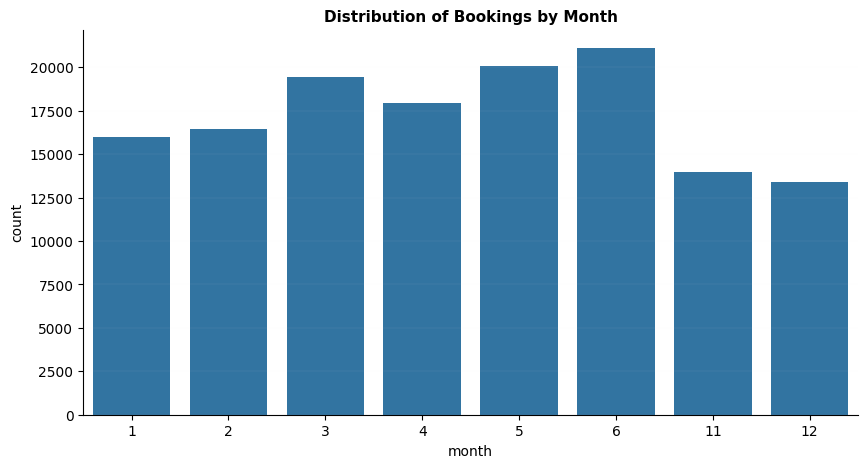

In [ ]:
def get_datetime(data):
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    return data

df = get_datetime(df)

# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()

In [ ]:
# Select numeric columns for statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate basic stats
stats = df[numeric_cols].describe().T.rename(columns={"50%": "median"})

# Calculate missing values
stats["missing"] = df[numeric_cols].isnull().sum()
stats["missing %"] = (stats["missing"] / len(df) * 100).round(1)

# Sort by missing % to identify problematic features (Task 3)
stats = stats.sort_values("missing %", ascending=False)
display(stats)

,count,mean,std,min,25%,median,75%,max,missing,missing %
comp1_rate_percent_diff,94439.0,244.229916,1165.448634,2.0000,7.000000,10.0000,16.000000,3.038900e+04,4863908,98.1
comp6_rate_percent_diff,96174.0,17.250473,31.160313,2.0000,6.000000,11.0000,18.000000,1.620000e+03,4862173,98.1
comp1_rate,119930.0,0.479788,0.641565,-1.0000,0.000000,1.0000,1.000000,1.000000e+00,4838417,97.6
comp1_inv,129559.0,0.031059,0.229688,-1.0000,0.000000,0.0000,0.000000,1.000000e+00,4828788,97.4
comp4_rate_percent_diff,131086.0,175.316533,5757.739837,2.0000,7.000000,11.0000,19.000000,1.001584e+06,4827261,97.4
comp7_rate_percent_diff,138515.0,19.433267,54.370221,2.0000,7.000000,12.0000,20.000000,9.900000e+03,4819832,97.2
gross_bookings_usd,138390.0,386.283316,821.190577,0.0000,124.000000,218.4000,429.790000,1.592924e+05,4819957,97.2
comp6_rate,240157.0,0.128329,0.559841,-1.0000,0.000000,0.0000,0.000000,1.000000e+00,4718190,95.2
visitor_hist_adr_usd,252988.0,176.022659,107.254493,0.0000,109.810000,152.2400,213.490000,1.958700e+03,4705359,94.9
visitor_hist_starrating,251866.0,3.374334,0.692519,1.4100,2.920000,3.4500,3.930000,5.000000e+00,4706481,94.9


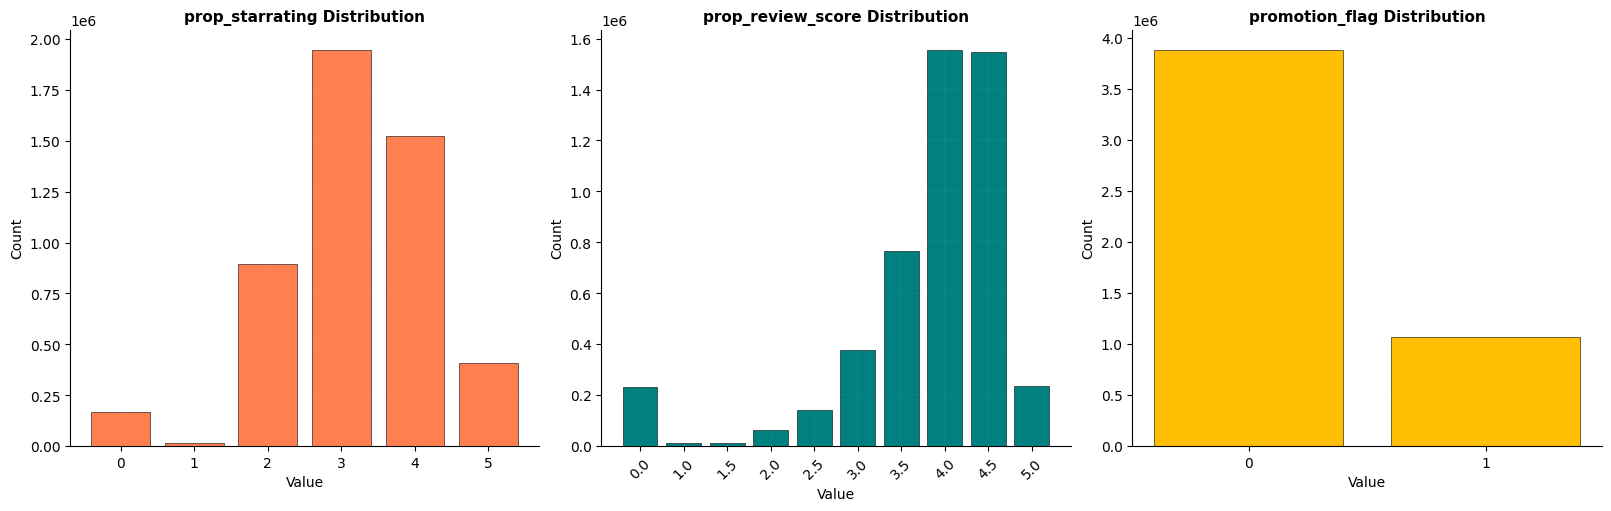

In [ ]:
# plotting key variables identified from literature
important_vars = ["prop_starrating", "prop_review_score", "promotion_flag"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

Conversion Rates by Saturday Night Stay:
   srch_saturday_night_bool  click_bool  booking_bool
0                         0    0.044510      0.027004
1                         1    0.044985      0.028809


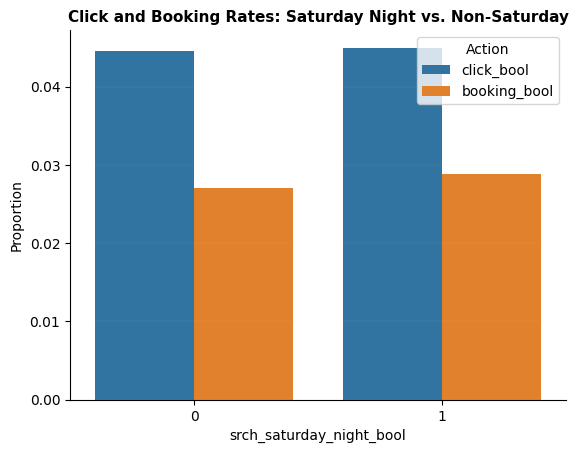

In [ ]:
def explore_saturday_stay(data):
    """checking if Saturday night impacts the clicks and bookings"""
    # group by the boolean flag
    stats = data.groupby('srch_saturday_night_bool').agg({
        'click_bool': 'mean',
        'booking_bool': 'mean'
    }).reset_index()

    print("Conversion Rates by Saturday Night Stay:")
    print(stats)

    # plot
    stats_melted = stats.melt(id_vars='srch_saturday_night_bool', value_vars=['click_bool', 'booking_bool'], var_name='Action', value_name='Rate')

    sns.barplot(data=stats_melted, x='srch_saturday_night_bool', y='Rate', hue='Action')
    plt.title('Click and Booking Rates: Saturday Night vs. Non-Saturday')
    plt.ylabel('Proportion')
    plt.show()

explore_saturday_stay(df)

Adding the relevance column to align with the evaluation metric

In [ ]:
# conditions
conditions = [
    (df['booking_bool'] == 1),
    (df['click_bool'] == 1)
]

# Define corresponding relevance grades
choices = [5, 1]

# Default to 0 if neither condition is met
df['relevance'] = np.select(conditions, choices, default=0)

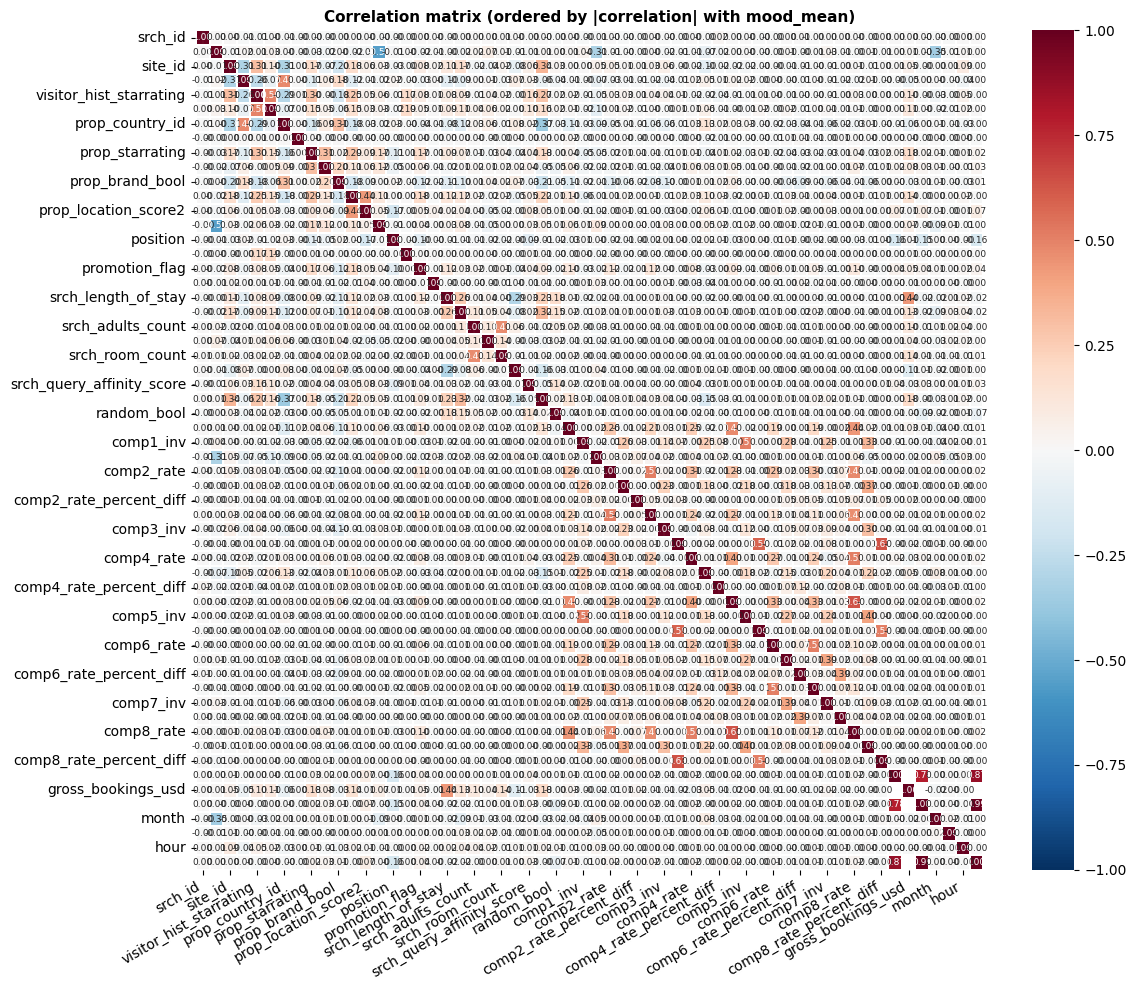

In [ ]:
corr  = df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={"size": 6.5}, ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
#plt.xticks(fontsize=7,rotation=40)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha="right")
plt.tight_layout()
#plt.savefig("figures/train_correlation_matrix.png", dpi=150)
plt.show()

In [ ]:
print("Shape:", df.shape)
print("Unique users:", df["srch_id"].nunique())

Shape: (4958347, 58)
Unique users: 199795


### Promotion flag

In [ ]:
# checking how the promotion flag correlates with the average position
promotion_stats = df.groupby('promotion_flag')['position'].mean().reset_index()

promotion_stats.columns = ['Promotion Flag', 'Average Position']
print(promotion_stats)

   Promotion Flag  Average Position
0               0         17.422649
1               1         14.795745


We see that the promotion flag means the average position is higher

In [ ]:
# BIAS: we use Independent Samples T-Test to check if this difference is statistically significant - if algorithm promotes discounted hotels
from scipy import stats

# separate data into two groups
group_no_promo = df[df['promotion_flag'] == 0]['position']
group_promo = df[df['promotion_flag'] == 1]['position']

#Welch's T-test
t_stat, p_value = stats.ttest_ind(group_no_promo, group_promo, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant (Reject H0).")
else:
    print("The difference is not statistically significant (Fail to reject H0).")


T-statistic: 230.9399
P-value: 0.0000e+00
The difference is statistically significant (Reject H0).


Since the dataset is very large, even small differences result in a statistically significant result, as in here. we should mention that while statistically significant, the practical significance (the ~2.6 rank jump) is what truly influences the user's likelihood to click or book.

Read to see what are the options:
https://towardsdatascience.com/a-complete-guide-to-recommender-system-tutorial-with-sklearn-surprise-keras-recommender-5e52e8ceace1/

## K-Nearest Neighbours
https://www.geeksforgeeks.org/machine-learning/recommender-systems-using-knn/


##